In [6]:
import pandas as pd

In [1]:
import numpy as np

In [9]:
# Nested dictionary using application_id as the primary key
# List of application dictionaries including missing values (None) and outliers
applications = [
    {
        "application_id": 1,
        "credit_score": 720,
        "monthly_income": 4500.00,
        "approved": True,
    },
    {
        "application_id": 2,
        "credit_score": 580,
        "monthly_income": 3200.00,
        "approved": False,
    },
    {
        "application_id": 3,
        "credit_score": 690,
        "monthly_income": 6100.00,
        "approved": True,
    },
    {
        "application_id": 4,
        "credit_score": 750,
        "monthly_income": 5200.00,
        "approved": True,
    },
    # Missing value: credit_score is unknown
    {
        "application_id": 5,
        "credit_score": None,
        "monthly_income": 3900.00,
        "approved": False,
    },
    # Outlier: monthly_income is extremely high ($1,500,000.00)
    {
        "application_id": 6,
        "credit_score": 820,
        "monthly_income": 1500000.00,
        "approved": True,
    },
    # Missing value: monthly_income is unknown
    {
        "application_id": 7,
        "credit_score": 610,
        "monthly_income": None,
        "approved": False,
    },
    # Outlier: credit_score is impossibly low (9), normally 300-850
    {
        "application_id": 8,
        "credit_score": 9,
        "monthly_income": 4100.00,
        "approved": False,
    },
    # Outlier: monthly_income is negative (-2500.00)
    {
        "application_id": 9,
        "credit_score": 640,
        "monthly_income": -2500.00,
        "approved": False,
    },
]

# Example: How to access a specific member's data
print(applications)  # Outputs: 580


[{'application_id': 1, 'credit_score': 720, 'monthly_income': 4500.0, 'approved': True}, {'application_id': 2, 'credit_score': 580, 'monthly_income': 3200.0, 'approved': False}, {'application_id': 3, 'credit_score': 690, 'monthly_income': 6100.0, 'approved': True}, {'application_id': 4, 'credit_score': 750, 'monthly_income': 5200.0, 'approved': True}, {'application_id': 5, 'credit_score': None, 'monthly_income': 3900.0, 'approved': False}, {'application_id': 6, 'credit_score': 820, 'monthly_income': 1500000.0, 'approved': True}, {'application_id': 7, 'credit_score': 610, 'monthly_income': None, 'approved': False}, {'application_id': 8, 'credit_score': 9, 'monthly_income': 4100.0, 'approved': False}, {'application_id': 9, 'credit_score': 640, 'monthly_income': -2500.0, 'approved': False}]


In [10]:
df = pd.DataFrame(applications)

In [11]:
df

,application_id,credit_score,monthly_income,approved
0,1,720.0,4500.0,True
1,2,580.0,3200.0,False
2,3,690.0,6100.0,True
3,4,750.0,5200.0,True
4,5,NaN,3900.0,False
5,6,820.0,1500000.0,True
6,7,610.0,NaN,False
7,8,9.0,4100.0,False
8,9,640.0,-2500.0,False


In [12]:

df = pd.DataFrame(applications)

# Calculate the median and fill missing values in place
median_score = df["credit_score"].median()

df["credit_score"] = df["credit_score"].fillna(median_score)

print(df)


   application_id  credit_score  monthly_income  approved
0               1         720.0          4500.0      True
1               2         580.0          3200.0     False
2               3         690.0          6100.0      True
3               4         750.0          5200.0      True
4               5         665.0          3900.0     False
5               6         820.0       1500000.0      True
6               7         610.0             NaN     False
7               8           9.0          4100.0     False
8               9         640.0         -2500.0     False


In [13]:


# Calculate the median and fill missing values in place
median_score2 = df["monthly_income"].median()
df["monthly_income"] = df["monthly_income"].fillna(median_score)

print(df)


   application_id  credit_score  monthly_income  approved
0               1         720.0          4500.0      True
1               2         580.0          3200.0     False
2               3         690.0          6100.0      True
3               4         750.0          5200.0      True
4               5         665.0          3900.0     False
5               6         820.0       1500000.0      True
6               7         610.0           665.0     False
7               8           9.0          4100.0     False
8               9         640.0         -2500.0     False


In [15]:

min_income = 3000.00
max_income = 6500.00

fdf = df[(df["monthly_income"] >= min_income) & (df["monthly_income"] <= max_income)]

print(fdf)


   application_id  credit_score  monthly_income  approved
0               1         720.0          4500.0      True
1               2         580.0          3200.0     False
2               3         690.0          6100.0      True
3               4         750.0          5200.0      True
4               5         665.0          3900.0     False
7               8           9.0          4100.0     False


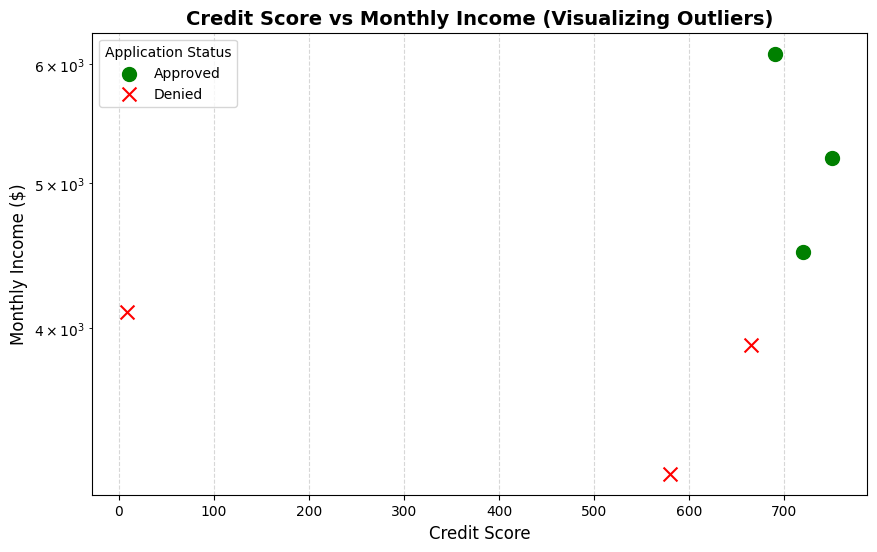

In [16]:
import matplotlib.pyplot as plt

approved = fdf[fdf["approved"] == True]
denied = fdf[fdf["approved"] == False]

# 4. Create the plot layout
plt.figure(figsize=(10, 6))

# Plot approved entries in green circles and denied entries in red X markers
plt.scatter(approved["credit_score"], approved["monthly_income"], color="green", marker="o", s=100, label="Approved")
plt.scatter(denied["credit_score"], denied["monthly_income"], color="red", marker="x", s=100, label="Denied")

# Add title, descriptive axis labels, and a chart grid
plt.title("Credit Score vs Monthly Income (Visualizing Outliers)", fontsize=14, fontweight="bold")
plt.xlabel("Credit Score", fontsize=12)
plt.ylabel("Monthly Income ($)", fontsize=12)
plt.legend(title="Application Status")
plt.grid(True, linestyle="--", alpha=0.5)

# Use log scale on the Y-axis so the $1,500,000 outlier doesn't squash the other points
plt.yscale("log") 

# Display the plot window
plt.show()


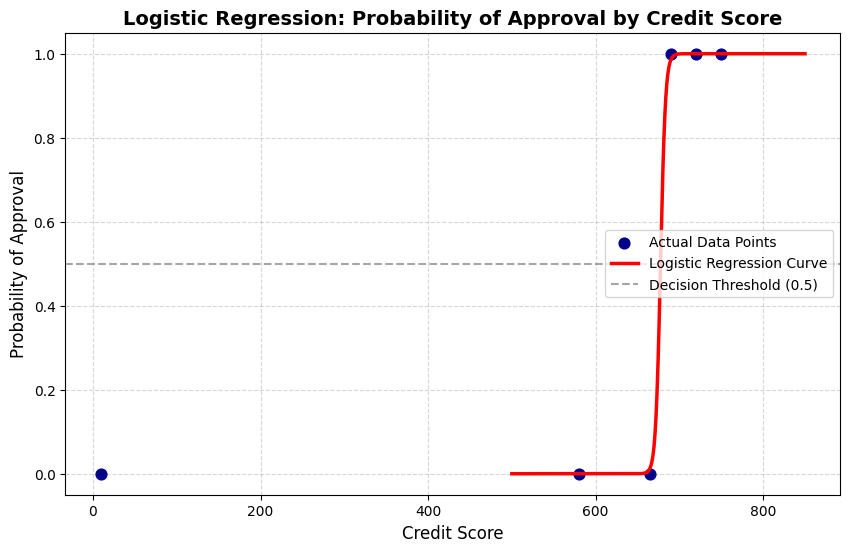

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = fdf[["credit_score"]].values  # Features matrix
y = fdf["approved"].values     # Target vector

# 5. Initialize and fit the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X, y)

# 6. Generate a smooth sequence of credit scores to plot the S-curve
X_range = np.linspace(500, 850, 300).reshape(-1, 1)
# Predict probabilities (index 1 gives the probability of being 'Approved')
y_prob = model.predict_proba(X_range)[:, 1]

# 7. Plotting the results
plt.figure(figsize=(10, 6))

# Plot the original cleaned data points at y=0 and y=1
plt.scatter(fdf["credit_score"], fdf["approved"], 
            color="darkblue", zorder=2, s=60, label="Actual Data Points")

# Plot the Logistic Regression probability curve (S-Curve)
plt.plot(X_range, y_prob, color="red", linewidth=2.5, label="Logistic Regression Curve")

# Add a 0.5 probability threshold line
plt.axhline(y=0.5, color="gray", linestyle="--", alpha=0.7, label="Decision Threshold (0.5)")

# Chart Formatting
plt.title("Logistic Regression: Probability of Approval by Credit Score", fontsize=14, fontweight="bold")
plt.xlabel("Credit Score", fontsize=12)
plt.ylabel("Probability of Approval", fontsize=12)
plt.ylim(-0.05, 1.05)  # Pad margins slightly above 1 and below 0
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="center right")

plt.show()